## Exercises

### Conceptual

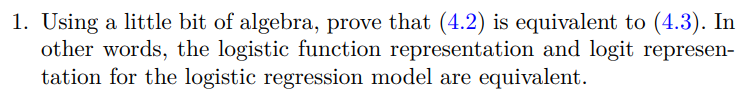
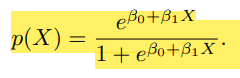
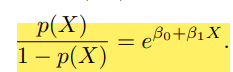

So, at first equation we see logistic function, that returns 0 and 1 - probababality, at the second equation we see logit representation:

$$p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$
Multiply both sides by:
$$
1 + e^{\beta_0 + \beta_1 X}$$
To get:
$$p(X) + p(X)e^{\beta_0 + \beta_1 X} = e^{\beta_0 + \beta_1 X}$$
Rearranging the terms:
$$
p(X) = e^{\beta_0 + \beta_1 X} - p(X)e^{\beta_0 + \beta_1 X}$$
Factoring out $e^{\beta_0 + \beta_1 X}$ and dividing both sides by the remainder:
$$\frac{p(X)}{1 - p(X)} = e^{\beta_0 + \beta_1 X}$$

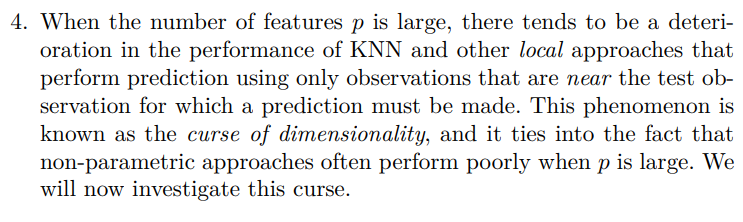

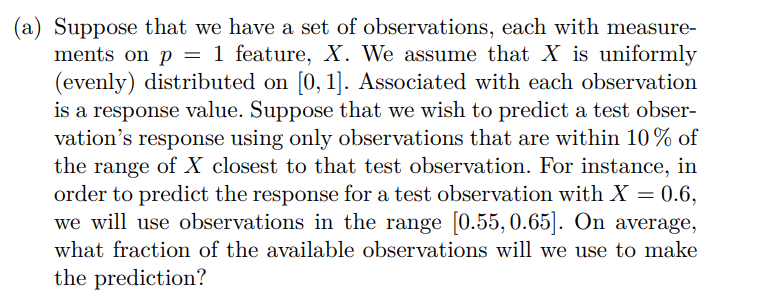

In [2]:
import numpy as np
import pandas as pd

obs = np.linspace(0, 1, 101)
range = 0.10
lim = range / 2

fractions = np.array([])

for test_obs in obs:
  left = test_obs - lim
  if left < 0:
    left = 0
    
  right = test_obs + lim
  if right > 1:
    right = 1
  
  fraction = right - left
  fractions = np.append(fractions, fraction)

print(fractions.mean())

0.09702970297029707


on average, the fraction of available observations we use to make the prediction is 9.7%, because if test points is in the start of in the end of interval, for example X = 0.02, so we can take negative numbers and will be = [X - 0.02, X + 0.05] = [0, 0.07], 7%, not 10%

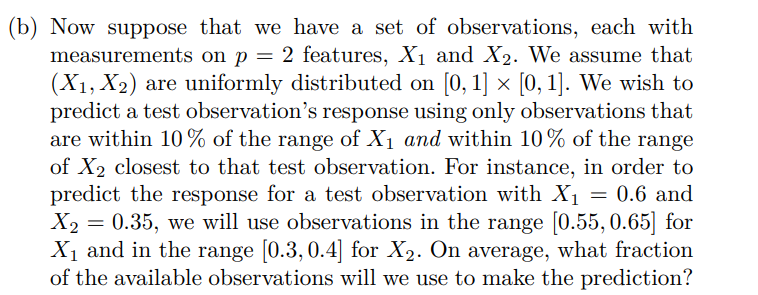

if we take higher dimensions, bunt ob thier own the fractions is the same - 0.97, then we can apply $a^{n}$

In [3]:
features = 2
fractions.mean() ** features

0.009414763258504077

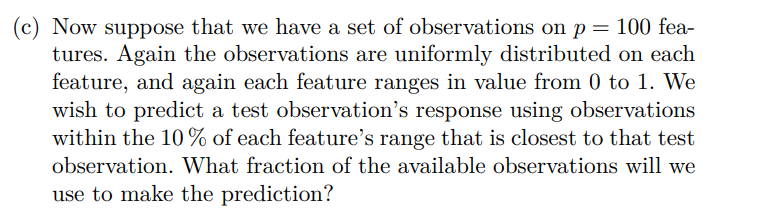

In [4]:
features = 100
fractions.mean() ** features

4.903093678840085e-102

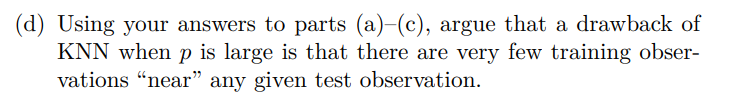

Now it`s obvious, because with higher dimension(num of features + 1), the number of used observartions in average is sligtly decresaig, because in case when all $X_i$ is some value in the start or in the end of range spoil all the pucture of this method, and it is very hard to find optimal nearest neighbors.

Also, with higher dimensions, the p-dimensional area is getting so big

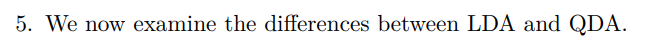

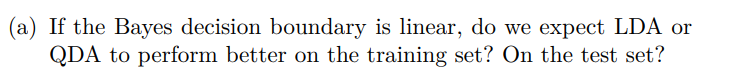

Bayes decision boundary

It’s the “gold standard” classifier: the one that minimizes test error if you knew the true class-conditional distributions.

Analogous to the “population regression line” in regression.

If the Bayes boundary is linear, that means the true conditional distributions (e.g. multivariate Gaussians with equal covariance matrices) lead to a linear separation rule.

So LDA is well-specified: it assumes linear boundaries, so it can match Bayes well (given enough data).

QDA is more flexible (quadratic boundary, separate covariance matrices for each class).

On the training set, QDA often fits better because it has more parameters and can “wiggle” to reduce training error.

But on the test set, since the true Bayes boundary is linear, that extra flexibility just adds variance → overfitting risk.

So LDA will usually do better on test in this situation.

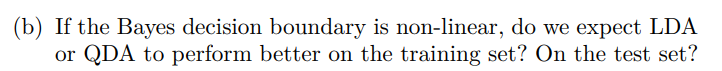

If the Bayes decision boundary is non-linear, that means that features are distributed with Gausisan distribution, but with difference covariance matrices.

If we have a lot amount pd data, that means that on the training and on the test set - QDA will better perform, because it has additional paramns to handle difficult patterns

But on small dataset, LDA can perform better on test set, since QDA will be overfitted by traning set

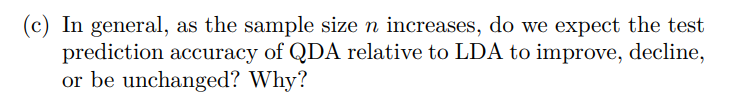

General principle

As n→∞, the effect of variance (overfitting) disappears — both LDA and QDA converge to their population versions.

So the relative performance depends only on how well their assumptions match the true distribution (i.e., whether the Bayes decision boundary is linear or not).

Two cases

Bayes decision boundary is linear (equal covariance matrices)

LDA is correctly specified → it converges to Bayes.

QDA is misspecified (too flexible) → still consistent, but with extra variance and unnecessary parameters.

With large 𝑛, LDA ≈ Bayes and outperforms QDA.

Bayes decision boundary is quadratic (different covariance matrices)

QDA is correctly specified → it converges to Bayes.

LDA is misspecified (can’t capture curvature) → always has bias.

With large 𝑛, QDA ≈ Bayes and outperforms LDA.

Small 𝑛

For small datasets, variance dominates → LDA may outperform QDA even if the Bayes boundary is quadratic.

This is the classic bias–variance tradeoff.

So the refined answer is:

As 𝑛 increases, the relative accuracy of QDA vs LDA depends on the true Bayes decision boundary.

If it’s linear, LDA does better in the limit.

If it’s non-linear, QDA does better in the limit. In general, the distribution of the data determines which model wins as the sample size grows.

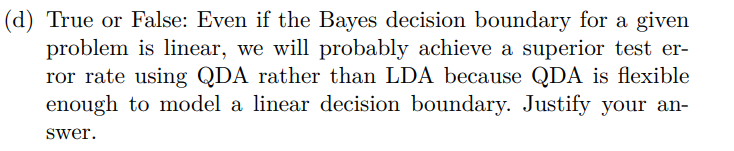

In case of linear Bayes decision boundary, we will achieve a superior test error using QDA, because QDA will have high variance. What this means? This means that QDA will strongly depend on chosen training dataset, and will be fitted to perform well ONLY on chosen traning dataset. BUT, if we choose another training set, or we choose some test set - the results will be very poor, since the Bayes decision boundary is linear, QDA will follow the noise, and will be oveerfitted.

Test error depends on bias-variance tradeoff, not flexibility.

Statement is false.

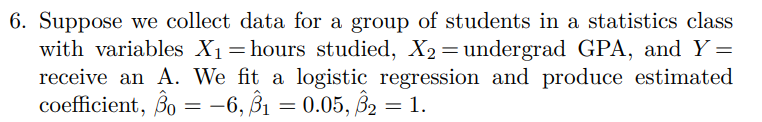

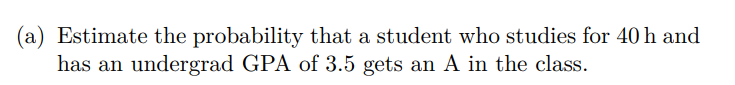

$X_1$ = hours studied \
$X_2$ = undergrad GPA \
Y = recieve an A

Used a logistic regression:
$$p(X)=\frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}.$$

$\beta_0$ = -6 \
$\beta_1$ = 0.05 \
$\beta_2$ = 1 

Test point:
- $X_1$ = 40
- $X_2$ = 3.5

In [5]:
betta_0 = -6 
betta_1 =  0.05
betta_2 =  1

def recieve_A(x1, x2):
  return (np.exp(betta_0 + betta_1 * x1 + betta_2 * x2)) /  \
         (1 + (np.exp(betta_0 + betta_1 * x1 + betta_2 * x2))) 

x1, x2 = 40, 3.5
prob =recieve_A(40, 3.5)
print(prob)

0.37754066879814546


The probability of recieving A is 38%

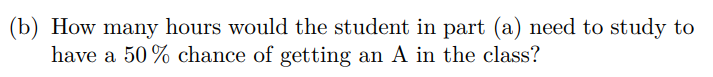

$$p(Hours,GPA)=\frac{e^{\beta_0+\beta_1*Hours+\beta_2*GPA}}{1+e^{\beta_0+\beta_1*Hours+\beta_2*GPA}}$$

In [6]:
hours_needed = 40
prob = 0.37754066879814546
gpa = 3.5

while prob < 0.5:
  hours_needed += 1
  prob = recieve_A(hours_needed, gpa)
  
print(hours_needed)
print(prob)

50
0.5


or we can take this formula:
$$\log \left( \frac{p(X)}{1 - p(X)} \right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$
where $X_1$ = hours needed

and derive to this:
$$X_1 = \frac{\log \left( \frac{p(X)}{1 - p(X)} \right) - \beta_0 - \beta_2 X_2}{\beta_1}
$$

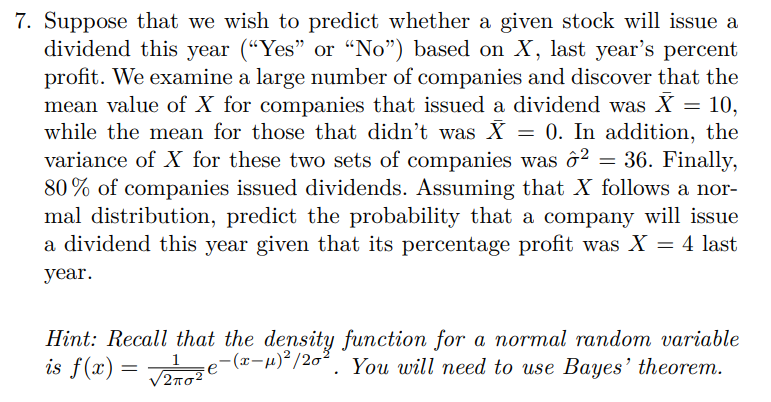

Y = "Yes" or "No" - will stock issue a divedend this year \
X - last year`s percent profit

We have two classes:
- A - company issue a divedend
- B - company does not issue a divedend

$\bar{X_A}=10$ - the mean value for X in A class \
$\bar{X_B}= 0$ - the mean value for X in A class

$\hat{\sigma_A}^{2} = \hat{\sigma_A}^{2} =36$ - variance of X is equal in class A and B

Since we know, that 80 % of companies issued dividends, I suppose that we can treat this as prior probability: \
$π_A = 0.8$ \
$π_B = 0.2$

Also we can assume that X followa a normal distribution


Based on facts above, we can use Bayes theorem and treat X as indepndent variable. We have prior and needed statistical values.

Posterior probability:$$\begin{aligned}
 & \Pr(Y=k|X=x)=\frac{\pi_k\times f_{k1}(x_1)\times f_{k2}(x_2)\times\cdots\times f_{kp}(x_p)}{\sum_{l=1}^K\pi_l\times f_{l1}(x_1)\times f_{l2}(x_2)\times\cdots\times f_{lp}(x_p)} \\
 & \mathrm{for~}k=1,\ldots,K.
\end{aligned}$$

First of all, for class A and class B we need probability density function, to describe how the X is distributed - $f(x_A)$ and $f(x_B)$

Since, X folloes Gaussian distribution, we can use its PDF:
$$f(x)=\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-(x-\mu)^{2}/2\sigma^{2}}$$

For Bayes theorem, we assume that all predctors are independent:
$$f_k(x) = f_{k1}(x_1) \times f_{k2}(x_2) \times \cdots \times f_{kp}(x_p),$$
but we have only one, so lets compute PDF for A and B

In [7]:
def gaussian_pdf(variance, mean, x):
    return (1 / np.sqrt(2 * np.pi * variance)) * np.exp(-((x - mean) ** 2) / (2 * variance))

In [8]:
mean_a = 10 
mean_b = 0
variance_a = variance_b = 36
x_test = 4

pdf_a = gaussian_pdf(variance_a, mean_a, x_test)
pdf_b = gaussian_pdf(variance_b, mean_b, x_test)

print(pdf_a)
print(pdf_b)

0.0403284540865239
0.053241334253725375


So know, we have some observation X = 4, and for each class compute posterior probability, and choose the max value of some kth class

In [16]:
import math

def bayes_theorem(priors, pdfs, k):
    numerator = priors[k] * pdfs[k]
    denominator = math.fsum(priors[j] * pdfs[j] for j in range(len(priors)))
    return numerator / denominator


In [20]:
priors = [0.8, 0.2]
pdfs = [0.0403284540865239, 0.053241334253725375]

prob_of_A = bayes_theorem(priors, pdfs, 0)
prob_of_B = bayes_theorem(priors, pdfs, 1)

print(prob_of_A)
print(prob_of_B)

TypeError: 'float' object is not callable

THe ourput should be: \
p(Y = A | X) = 0.7516528925619835 \
p(Y = B | X) = 0.24834710743801653 

but my code do not want to work), though it has no errors

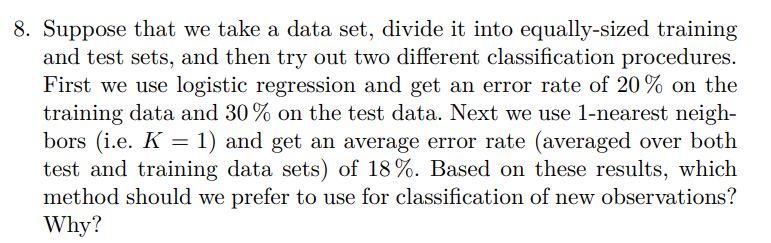

Lets make some notes:

Logistic regression:
- training error rate: 20%
- test error rate: 30%

1-nearest neighbors:
- average error rate: (training + test) / 2 = 18%

So, if we look at logistic regression and its results, the accuracy is not bad, and it is obvious that test error rate is higher then training

But, the main moment is in 1-nearest neighbors: average error rate = 18%.
At first it looks that this model better did its job, but...

The main idea of fitting models is to reduce TEST error. We do not care about training if our test error is high. So, it can be possible that training error rate is 0% and test is 36% and in average this is 18%. ALso it has 1 neighbor which is very flexible model

Logistic - high bias, low varince
1-nearest - low bias, high variance

Logistic regression is better because we care about test error, not traning or average